# Cleaning C19 American literature records from LC MDS books data

- This notebook continues from the previous notebook.
- The overarching purpose of the cleaning steps undertaken here are to **normalize places of publication** for long nineteenth century works of US literature.
- Extract the `PS` range for American literature
  - See the [LC Classification Outline](https://www.loc.gov/aba/cataloging/classification/lcco/) for information about specific ranges
- Filter `PS` range for American literature (`PS` includes Canadian lit, too)
- Get publication years and `PS` lead digits as integers for sorting
- Clean places of publication

In [1]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("../src")

from data_collection import *
from data_cleaning import *

In [2]:
# change to your local path based on the output of the previous notebook:
output_dir = "/Users/erik/Desktop/LC_PS"

df = load_pickles_to_dataframe(output_dir)

# Confirm expected shape
df.shape == (303567, 7)

df = df.copy()

In [3]:
df["ps_digits"] = df["classifications"].apply(
    lambda x: [get_ps_digits(y) for y in x if "PS" in y][0]
)

In [4]:
# PS(8001-8599) == Canadian literature
df["is_canadian"] = df["ps_digits"] > 8000

In [5]:
# Drop Canadian records
df = df[~df["is_canadian"]]

In [6]:
df["year_int"] = df["year"].apply(get_years_ints)

In [7]:
df["publisher_year_int"] = df["publishers"].apply(get_publishers_year_ints)

In [8]:
# combine_first integers from publishers and year columns
df["year_publisher_int"] = df["year_int"].combine_first(df["publisher_year_int"])

In [9]:
df["min_year"] = df.apply(get_min_year, axis=1)

In [10]:
# Fill missing values with min year 0
df["min_year"] = df["min_year"].fillna(0).astype(int)

In [11]:
df["places_clean"] = df["places"].apply(lambda x: [clean_string(s) for s in x])

In [12]:
df["places_clean"] = df["places_clean"].apply(flatten_list)

In [13]:
cols = ["lccn", "classifications", "year", "places", "publishers"]

for col in cols:
    df[col] = clean_col(df, col)

In [14]:
df["decade"] = df["min_year"].apply(get_decade)

In [15]:
# add boolean for if places is list with length > 1
df["multiple_places"] = df["places_clean"].apply(lambda x: len(x) > 1)

In [16]:
df_exploded = df.explode("places_clean")

In [17]:
df_exploded["target_city"] = df_exploded["places_clean"].apply(get_target_cities)

In [18]:
df_exploded = df_exploded.explode("target_city")

In [19]:
df_exploded["new_york"] = df_exploded["target_city"] == "New York"

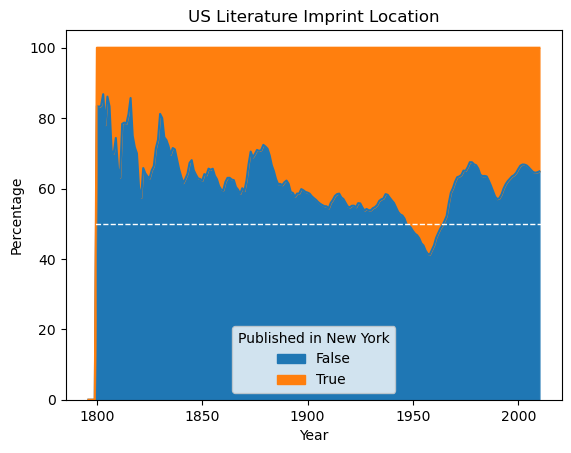

In [20]:
plot_df = (
    df_exploded[(df_exploded["min_year"] >= 1796) & (df_exploded["min_year"] <= 2010)]
    .groupby(["min_year", "new_york"])
    .size()
    .unstack()
    .fillna(0)
    .rolling(5)
    .mean()
)

# plot_df = (
#     df_exploded[(df_exploded["min_year"] >= 1796) & (df_exploded["min_year"] <= 2010)]
#     .groupby(["min_year", "new_york"])
#     .size()
#     .unstack()
#     .fillna(0)
# )

plot_df = plot_df.div(plot_df.sum(axis=1), axis=0) * 100

import matplotlib.pyplot as plt

# plt.style.use("seaborn-v0_8-colorblind")

# plt.figure(dpi=600)
plot_df.plot(kind="area", stacked=True)
plt.style.use("tableau-colorblind10")
plt.axhline(y=50, color="white", linestyle="--", linewidth=1)
plt.title("US Literature Imprint Location")
plt.xlabel("Year")
plt.ylabel("Percentage")
plt.legend(title="Published in New York")

plt.savefig("/Users/erik/Downloads/fig.png", dpi=600)

Slope: 0.1601
Intercept: -263.5737
R^2 score: 0.6800
Predicted percentage of works published in New York in the year 2000: 56.71%


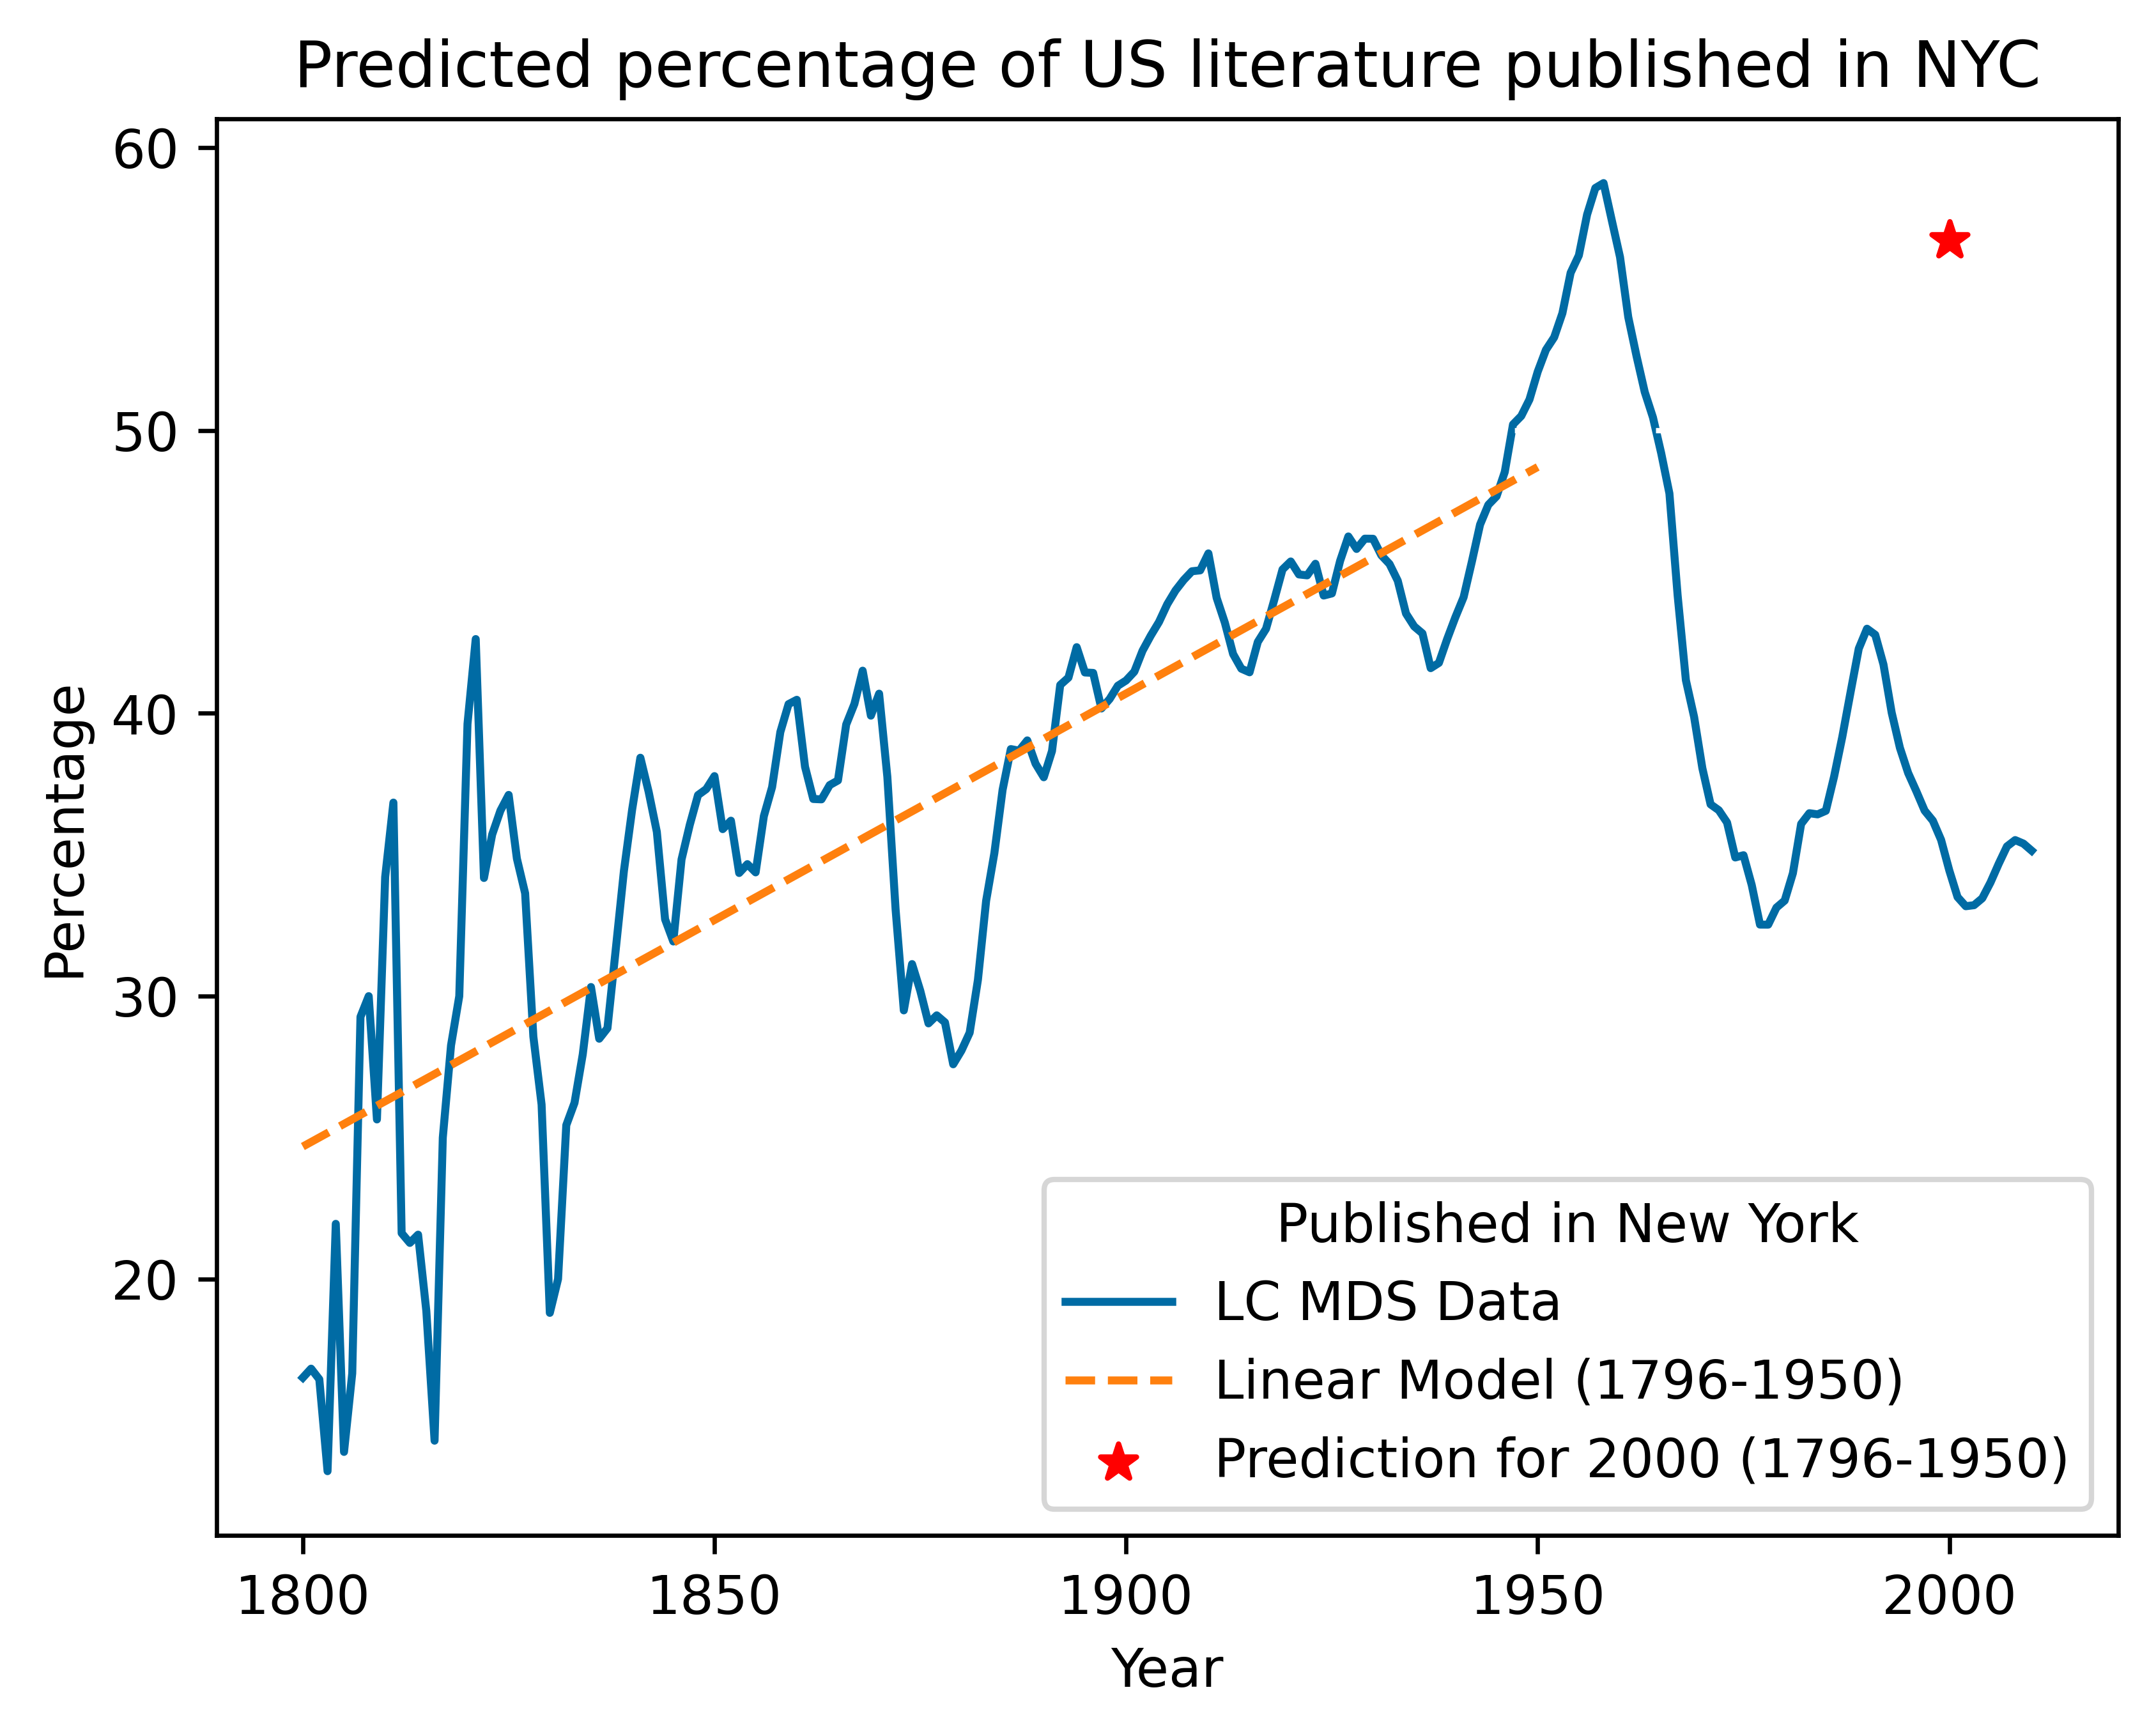

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Recreate the plot_df dataset filtering for min_year between 1796 and 1950
plot_df = (
    df_exploded[(df_exploded["min_year"] >= 1796) & (df_exploded["min_year"] <= 2010)]
    .groupby(["min_year", "new_york"])
    .size()
    .unstack()
    .fillna(0)
    .rolling(5)
    .mean()
)

plot_df = plot_df.div(plot_df.sum(axis=1), axis=0) * 100

# Filter for min_year between 1796 and 1950
filtered_df = plot_df.loc[1796:1950]

# Prepare the data for the linear model
X = filtered_df.index.values.reshape(-1, 1)  # Years as the independent variable
y = filtered_df[
    True
].values  # Percentage of works published in New York as the dependent variable

# Remove rows with NaN values in y
mask = ~np.isnan(y)
X = X[mask]
y = y[mask]

# Fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Extract the model coefficients
slope = model.coef_[0]
intercept = model.intercept_

print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")

# Determine model quality using R^2 score
r_squared = model.score(X, y)
print(f"R^2 score: {r_squared:.4f}")

# Predict the value for the year 2000
year_2000 = np.array([[2000]])
predicted_value_2000 = model.predict(year_2000)

print(
    f"Predicted percentage of works published in New York in the year 2000: {predicted_value_2000[0]:.2f}%"
)

# Plot the data and the linear model
plt.figure(dpi=600)
plt.style.use("tableau-colorblind10")
plt.plot(plot_df.index, plot_df[True], label="LC MDS Data")
plt.plot(
    filtered_df.index[mask],
    model.predict(X),
    label="Linear Model (1796-1950)",
    linestyle="--",
)
plt.scatter(
    year_2000,
    predicted_value_2000,
    color="red",
    label="Prediction for 2000 (1796-1950)",
    marker="*",
    s=50,
)
plt.axhline(y=50, color="white", linestyle="--", linewidth=1)
plt.title("Predicted percentage of US literature published in NYC")
plt.xlabel("Year")
plt.ylabel("Percentage")
plt.legend(title="Published in New York")
plt.savefig("/Users/erik/Downloads/fig_with_prediction.png", dpi=600)
plt.show()

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

# Recreate the plot_df dataset filtering for min_year between 1796 and 1950
plot_df = (
    df_exploded[(df_exploded["min_year"] >= 1796) & (df_exploded["min_year"] <= 2010)]
    .groupby(["min_year", "new_york"])
    .size()
    .unstack()
    .fillna(0)
    .rolling(5)
    .mean()
)

plot_df = plot_df.div(plot_df.sum(axis=1), axis=0) * 100

plot_df[plot_df[True] >= 50]

plot_df[plot_df.index == 2000]

new_york,False,True
min_year,,
2000,65.559228,34.440772


R^2 score for LOESS: 0.7873
Predicted percentage of works published in New York in the year 2000: 79.18%


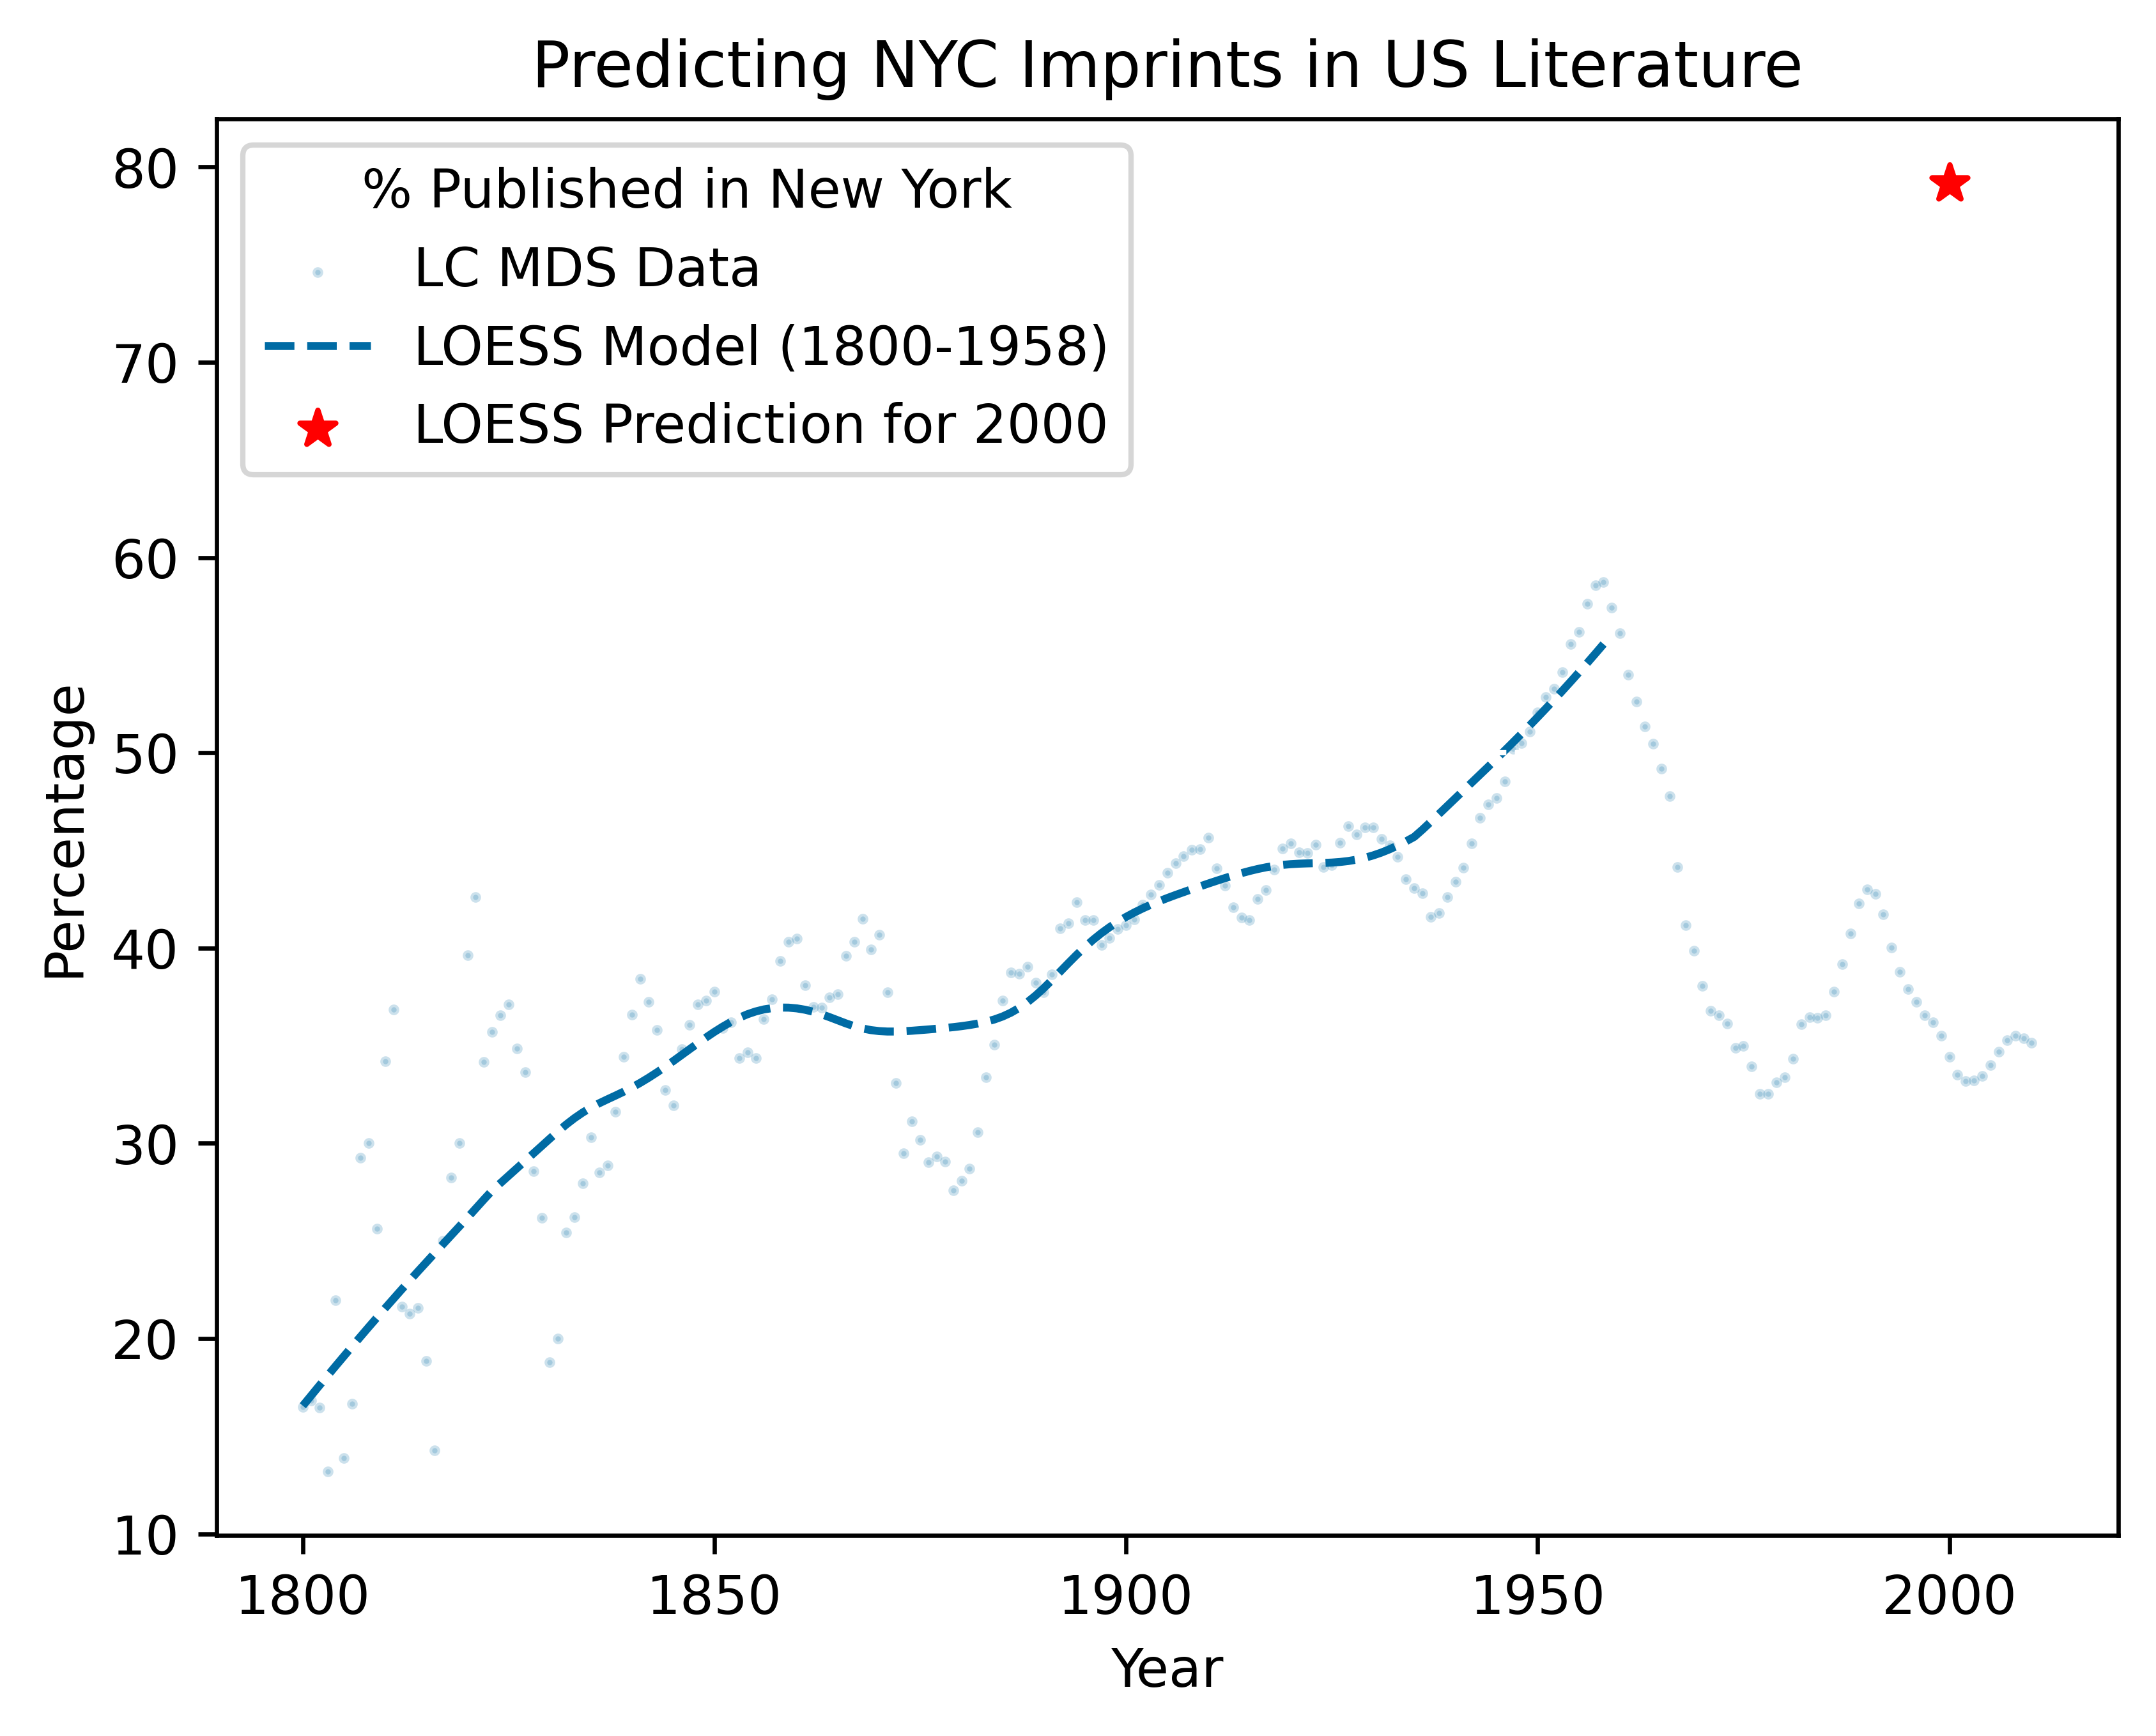

In [ ]:
# Filter for min_year between 1796 and 1959
filtered_df = plot_df.loc[1796:1958]

# Prepare the data for the LOESS model
X = filtered_df.index.values  # Years as the independent variable
y = filtered_df[
    True
].values  # Percentage of works published in New York as the dependent variable

# Remove rows with NaN values in y
mask = ~np.isnan(y)
X = X[mask]
y = y[mask]

# Fit the LOESS model
loess_result = lowess(y, X, frac=0.3)  # Adjust frac as needed for smoothing
loess_x = loess_result[:, 0]
loess_y = loess_result[:, 1]

# Determine model quality using R^2 score for LOESS
y_pred_loess = np.interp(X, loess_x, loess_y)
ss_res = np.sum((y - y_pred_loess) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r_squared_loess = 1 - (ss_res / ss_tot)
print(f"R^2 score for LOESS: {r_squared_loess:.4f}")

# Predict the value for the year 2000 using LOESS
year_2000 = np.array([2000])
predicted_value_2000 = lowess(y, X, frac=0.3, xvals=year_2000)

print(
    f"Predicted percentage of works published in New York in the year 2000: {predicted_value_2000[0]:.2f}%"
)

# Plot the data and the LOESS model
plt.figure(dpi=600)
plt.style.use("tableau-colorblind10")
plt.scatter(plot_df.index, plot_df[True], label="LC MDS Data", alpha=0.2, s=1)
plt.plot(loess_x, loess_y, label="LOESS Model (1800-1958)", linestyle="--")
plt.scatter(
    year_2000,
    predicted_value_2000,
    color="red",
    marker="*",
    s=50,
    label="LOESS Prediction for 2000",
)
plt.axhline(y=50, color="white", linestyle="--", linewidth=1)
plt.title("Predicting NYC Imprints in US Literature")
plt.xlabel("Year")
plt.ylabel("Percentage")
plt.legend(title="% Published in New York")
plt.savefig("/Users/erik/Downloads/fig_with_loess_prediction.png", dpi=600)
plt.show()

In [22]:
# Create the data set
df_c19 = df_exploded.copy()
df_c19 = df_c19[
    [
        "lccn",
        "classifications",
        "ps_digits",
        "first_author",
        "title",
        "publishers",
        "min_year",
        "places",
        "multiple_places",
        "target_city",
    ]
]
df_c19 = df_c19[(df_c19["min_year"] <= 1945) & (df_c19["min_year"] >= 1600)]
df_c19.sort_values("ps_digits", inplace=True)
df_c19.to_csv("../data/data.csv", index=False)